# Flagging Vendor Invoices for Manual Review

**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

* Manual invoice review is time-consuming and does not scale with transaction volume.
* Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
* An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.
*

In [55]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
conn = sqlite3.connect(r"C:\Users\amalr\Downloads\inventory.db")

In [57]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'",
    conn
) 
for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql(f"select* from {table} limit 5",conn))
   

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [58]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay

from purchases p
group by p.PONumber
""",conn)

In [59]:
pd.read_sql_query("""
select
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) As days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.PODate)) As days_to_pay
from vendor_invoice vi
""",conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,57.0
1,15,140.55,8.57,16.0,61.0
2,5,106.60,4.61,16.0,54.0
3,10100,137483.78,2935.20,23.0,47.0
4,1935,15527.25,429.20,14.0,50.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,51.0
5539,4617,37300.48,186.50,18.0,57.0
5540,9848,202815.78,932.95,11.0,44.0
5541,24747,149007.56,819.54,14.0,50.0


In [60]:
purchase_agg_df.shape

(5543, 5)

In [61]:
df = pd.read_sql_query("""
    WITH purchase_agg As (
        SELECT
            p.PONumber,
            count(distinct p.Brand) as total_brands,
            sum(p.Quantity) as total_item_quantity,
            sum(p.Dollars) as total_item_dollars,
            avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
            
        from purchases p
        group by p.PONumber
    )
    SELECT
        vi.Quantity as invoice_quantity,
        vi.Dollars as invoice_dollars,
        vi.Freight,
        (julianday(vi.InvoiceDate) - julianday(vi.PODate)) As days_po_to_invoice,
        (julianday(vi.PayDate) - julianday(vi.PODate)) As days_to_pay,
        pa.total_brands,
        pa.total_item_quantity,
        pa.total_item_dollars,
        pa.avg_receiving_delay
    
    FROM vendor_invoice vi
    LEFT JOIN purchase_agg pa
        ON vi.PONumber = pa.PONumber
    
    """,conn)

In [62]:
df

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,6,214.26,3.47,14.0,57.0,1,6,214.26,12.000000
1,15,140.55,8.57,16.0,61.0,2,15,140.55,10.333333
2,5,106.60,4.61,16.0,54.0,1,5,106.60,9.000000
3,10100,137483.78,2935.20,23.0,47.0,81,10100,137483.78,12.614130
4,1935,15527.25,429.20,14.0,50.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,51.0,2,223,6823.18,5.871795
5539,4617,37300.48,186.50,18.0,57.0,110,24747,149007.56,5.050500
5540,9848,202815.78,932.95,11.0,44.0,5,180,2559.72,5.000000
5541,24747,149007.56,819.54,14.0,50.0,83,43240,318075.65,8.045541


In [63]:
df.isnull().sum()

invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [64]:
df.dtypes

invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [65]:
def create_invoice_risk_label(row):

    #invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
    #Abnormally high recieving delay
    if row["avg_receiving_delay"] > 10 : 
        return 1
    return 0 

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

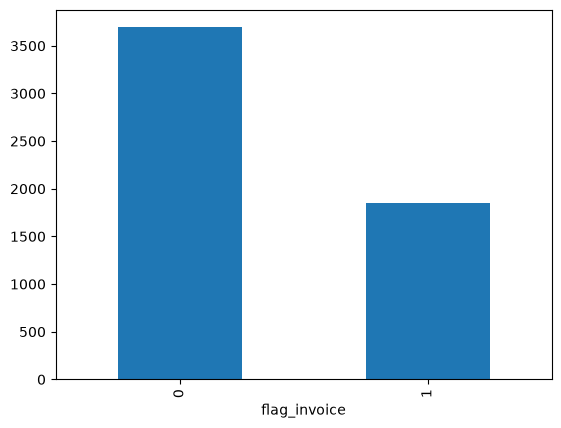

In [66]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

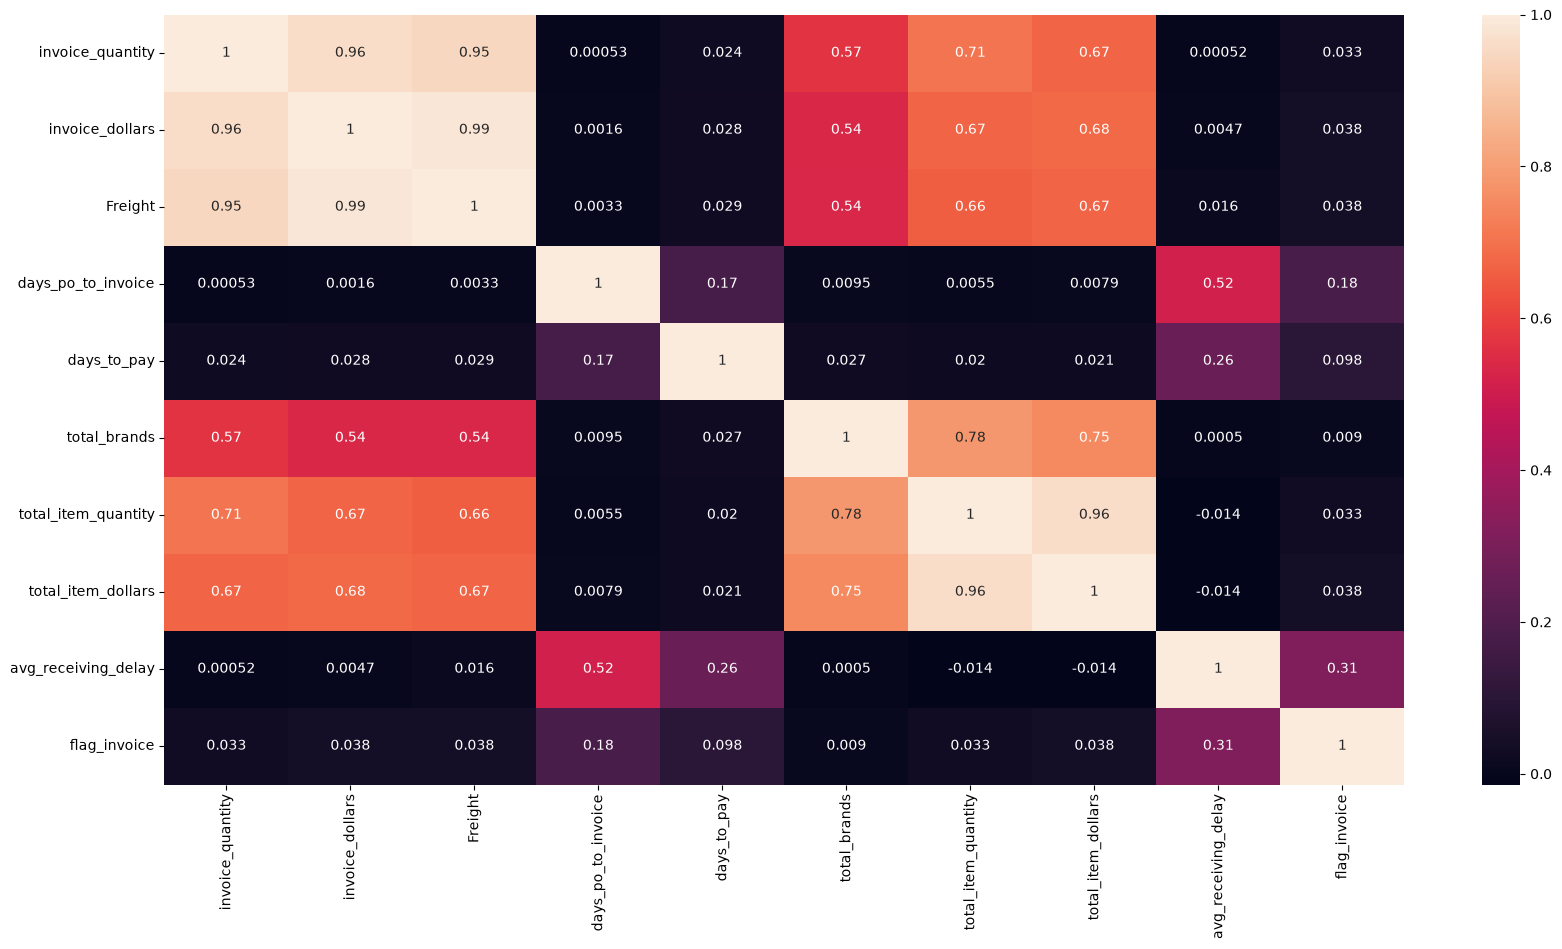

In [67]:
plt.figure(figsize = (20,10))
sns.heatmap(df.corr(),annot = True)
plt.show()

In [68]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [73]:
significant_features = []
non_significant_features = []
results = []

In [74]:
metrics = ['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'days_to_pay',
 'total_brands',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [80]:
from scipy.stats import ttest_ind



for metric in metrics:

    flagged_mean = flagged[metric].dropna().mean()
    normal_mean = normal[metric].dropna().mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
    
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
     })

    else:
        non_significant_features.append(metric)
        print(metric)
        print({
        "metric": metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value": p_value.round(3)})  


total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [81]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'days_to_pay',
  'flagged_mean': np.float64(52.66),
  'normal_mean': np.float64(51.51),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receivi

In [84]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice','days_to_pay', 'total_item_dollars']]
y = df['flag_invoice']

In [86]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,days_to_pay,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,52.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,6.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,40.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,47.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,52.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,56.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,63.0,1660436.0


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [104]:
print(y_train.value_counts())
print(y_test.value_counts())

flag_invoice
0    2968
1    1466
Name: count, dtype: int64
flag_invoice
0    725
1    384
Name: count, dtype: int64


In [98]:
print(X_train.shape)
print(X_test.shape)

(4434, 8)
(1109, 8)


In [99]:
print(X_train.head())

      invoice_quantity  invoice_dollars  Freight  total_brands  \
2609                24           264.24     1.37             2   
5527                36           342.48     1.75           101   
5321                30           572.40     2.63            66   
3805             10721         68821.14   344.11            62   
1215             80495        604197.73  2900.15           250   

      total_item_quantity  days_po_to_invoice  days_to_pay  total_item_dollars  
2609                   24                15.0         52.0              264.24  
5527                30817                15.0         43.0           322230.77  
5321                 7447                16.0         53.0            49281.22  
3805                10721                14.0         43.0            68821.14  
1215                80495                20.0         61.0           604197.73  


In [100]:
print(X_train.head())

      invoice_quantity  invoice_dollars  Freight  total_brands  \
2609                24           264.24     1.37             2   
5527                36           342.48     1.75           101   
5321                30           572.40     2.63            66   
3805             10721         68821.14   344.11            62   
1215             80495        604197.73  2900.15           250   

      total_item_quantity  days_po_to_invoice  days_to_pay  total_item_dollars  
2609                   24                15.0         52.0              264.24  
5527                30817                15.0         43.0           322230.77  
5321                 7447                16.0         53.0            49281.22  
3805                10721                14.0         43.0            68821.14  
1215                80495                20.0         61.0           604197.73  


In [101]:
print("Model 1 classes:", model1.classes_)
print("Model 2 classes:", model2.classes_)
print("Model 3 classes:", model3.classes_)

Model 1 classes: [0 1]
Model 2 classes: [0 1]
Model 3 classes: [0 1]


In [102]:
print("Logistic Regression predictions:")
print(pd.Series(model1.predict(X_test_scaled)).value_counts())

print("\nDecision Tree predictions:")
print(pd.Series(model2.predict(X_test_scaled)).value_counts())

print("\nRandom Forest predictions:")
print(pd.Series(model3.predict(X_test_scaled)).value_counts())

Logistic Regression predictions:
0    1058
1      51
Name: count, dtype: int64

Decision Tree predictions:
0    756
1    353
Name: count, dtype: int64

Random Forest predictions:
0    840
1    269
Name: count, dtype: int64


In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression()
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [106]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')

evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy: 0.66

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.97      0.79       725
           1       0.55      0.07      0.13       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.46      1109
weighted avg       0.62      0.66      0.56      1109


Decision Tree Classifier Performance:
Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       725
           1       0.72      0.66      0.69       384

    accuracy                           0.79      1109
   macro avg       0.77      0.76      0.77      1109
weighted avg       0.79      0.79      0.79      1109


Random Forest Classifier Performance:
Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       725
        

{'model_name': 'Random Forest Classifier', 'accuracy': 0.8656447249774571}

In [107]:
model3.feature_importances_

array([0.13271246, 0.14240852, 0.13887481, 0.08942065, 0.16651771,
       0.07565207, 0.06177715, 0.19263663])

In [108]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
7,total_item_dollars,0.192637
4,total_item_quantity,0.166518
1,invoice_dollars,0.142409
2,Freight,0.138875
0,invoice_quantity,0.132712
3,total_brands,0.089421
5,days_po_to_invoice,0.075652
6,days_to_pay,0.061777


In [110]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier Performance:
Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



{'model_name': 'Random Forest Classifier', 'accuracy': 0.8845807033363391}

In [114]:


param_grid = {
    "n_estimators":[100,200,300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split":[2,3,5],
    "min_samples_leaf":[1,2,5],
    "criterion": ['gini', 'entropy']
}


In [115]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



{'model_name': 'Random Forest Classifier', 'accuracy': 0.8899909828674482}

In [116]:
from sklearn.metrics import confusion_matrix

In [117]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 110],
       [ 12, 274]])

In [118]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]])

In [120]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}